## Model Setup

In [ ]:
network_data = 'nets/siren/first_300_320.pt'
time = 30.2
step =1

In [2]:
import torch
import numpy as np
from Modules.Neural_Net import Net
import Modules.preprocess as pp
import re
#This defines where the data is
data  = torch.load('../../data/data.pt', weights_only=True)
nums = re.findall(r'\d+', network_data)  
first, second = map(int, nums[:2]) 
frames = np.arange(first, second, step=step)


train_beams = list(range(0, 32))
model = torch.load(network_data, weights_only = False)

#This generates the data
train_data = pp.data_gen(data, beams = train_beams, frames=frames, normalize=model['scalers'], splits =.99)
train_dataloader, q  = train_data.get_dataloaders(train_data, batch_size=1, num_workers=4)

#This makes the model
net = Net(torch.sin, *model['model config']).to('cpu')
net.load_state_dict(model['model_state_dict'])
net.eval()
print('done')

ModuleList(
  (0): Linear(in_features=3, out_features=280, bias=True)
  (1): Linear(in_features=280, out_features=550, bias=True)
  (2): Linear(in_features=550, out_features=1000, bias=True)
  (3): Linear(in_features=1000, out_features=100, bias=True)
)
ModuleList(
  (0): Linear(in_features=3, out_features=280, bias=True)
  (1): Linear(in_features=280, out_features=550, bias=True)
  (2): Linear(in_features=550, out_features=1000, bias=True)
  (3): Linear(in_features=1000, out_features=1000, bias=True)
  (4): Linear(in_features=1000, out_features=550, bias=True)
  (5): Linear(in_features=550, out_features=280, bias=True)
  (6): Linear(in_features=280, out_features=100, bias=True)
  (7): Linear(in_features=100, out_features=100, bias=True)
)
done


In [3]:
from Modules.evaluate import Evaluator
from Modules.evaluate import pick_data

time = time

def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)

inputs = torch.load('Modules/plotting_region.pt', weights_only = True)
inputs = add_t(inputs,time )


evaluator = Evaluator(net, scalers = model['scalers'], inputs=inputs)
pred_z = evaluator.net_eval()

raw = pick_data(data=data, beams= train_beams, frames =frames)
raw_in, raw_out = raw.data_out_numpy(time)
print(raw_in.shape)
raw_x = raw_in[:,0]
raw_y = raw_in[:,1]
raw_z = raw_out

x = inputs[:, 0].reshape(-1, 1).detach().numpy()
y = inputs[:, 1].reshape(-1, 1).detach().numpy()



Raw network output range: -1.552 to 4.819
(17611, 3)


In [4]:



# 1. Check what Evaluator actually returns
outputs = evaluator.net_eval()
print(f"Final output shape: {outputs.shape}")
print(f"Final output range: {outputs.min():.3f} to {outputs.max():.3f}")
print(f"Final output std: {outputs.std():.3f}")

# 2. Check if it's a plotting issue
print(f"Unique values in output: {len(torch.unique(outputs))}")

# 3. Verify scaler is being used
print(f"Evaluator has out_scaler: {evaluator.out_scaler is not None}")

Raw network output range: -1.552 to 4.819
Final output shape: torch.Size([30000, 1])
Final output range: 0.675 to 4.623
Final output std: 0.736
Unique values in output: 29947
Evaluator has out_scaler: True


## Data vs Model Predictions

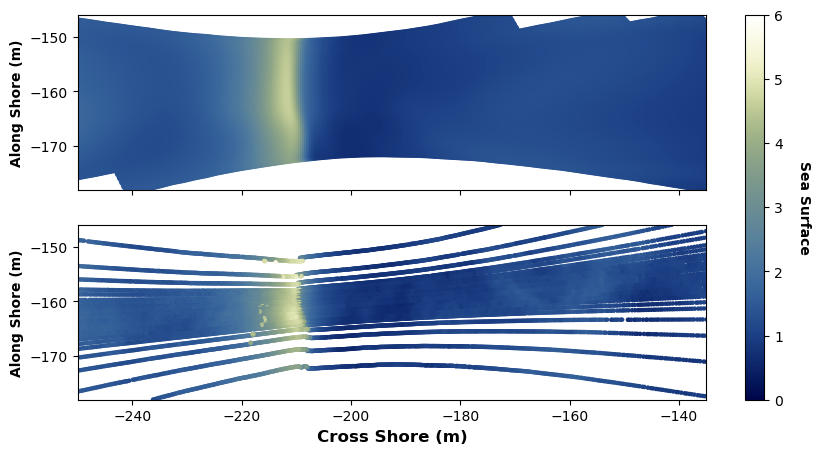

In [5]:
# Make the pretty plot 
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri.cm as cmc

#Make the plot

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,5))
im1 = ax1.scatter(x, y, c=pred_z, vmin=0, vmax=6, cmap=cmc.davos)
scat = ax2.scatter(raw_x, raw_y, c = raw_z, vmin=0, vmax=6, cmap=cmc.davos, s =5)

ax1.set_aspect('equal')
ax2.set_aspect('equal')

ax1.set_xlim(-250, -135)
ax1.set_ylim(-178, -146)
ax2.set_xlim(-250, -135)
ax2.set_ylim(-178, -146)

ax1.set_xticklabels([])


ax2.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
ax1.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)    
ax2.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)

cbar = fig.colorbar(im1, ax=[ax1, ax2], location='right', shrink=1.0, aspect=20, fraction = .05)
cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)

# save = f"figures/frame_{frame:03d}.png"
# plt.savefig(save, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Hovemoller

Raw network output range: -4.362 to 4.854


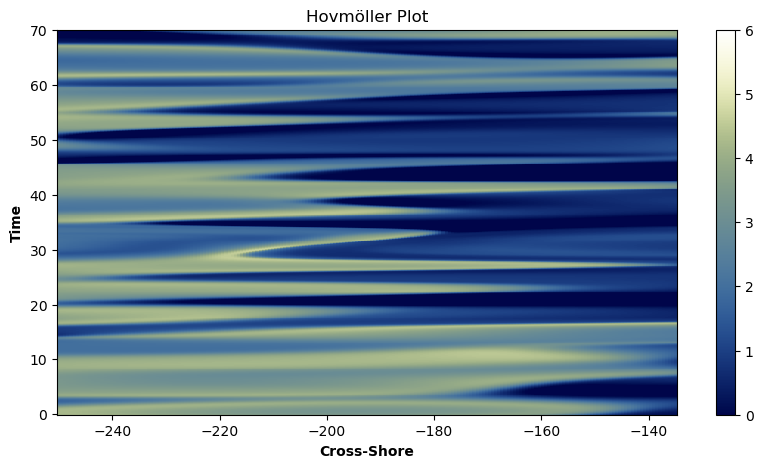

In [6]:
'Hovomollar plot'
device = 'cpu'

x = torch.linspace(-250, -135, 200)
y = -162.5
t = torch.linspace(0,70 , 400)
X, T = torch.meshgrid(x, t, indexing='ij')
grid_xyt = torch.stack((X.flatten(), torch.ones(X.numel()).to(device)*y, T.flatten()), dim=-1).to(device)

evalulator = Evaluator(net = net, scalers= model['scalers'], inputs=grid_xyt)

with torch.no_grad():
    pred = evalulator.net_eval()

    Z = pred[:,0].reshape(X.shape)

fig, ax = plt.subplots(figsize=(10,5))
im = ax.pcolormesh(X, T, Z, cmap=cmc.davos, shading='auto', vmin = 0, vmax =6)
plt.colorbar(im, ax=ax)
ax.set_xlabel('Cross-Shore', fontweight = 'bold')
ax.set_ylabel('Time', fontweight = 'bold')
ax.set_title('Hovmöller Plot')
plt.savefig('../latex/overleaf/figures/hovmoller_plot.pdf', dpi=300, bbox_inches='tight')



## Derivatives Plot

- Here we need to be carefull about our net eval. 

In [8]:
from Modules.gradients import take_grad
def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)

inputs = torch.load('Modules/plotting_region.pt', weights_only = True)
inputs = add_t(inputs, 30)
inputs = inputs.requires_grad_(True)


evalulator = Evaluator(net, scalers = model['scalers'], inputs=inputs)
pred_z = evalulator.net_eval_with_grad()

operator = take_grad(inputs = inputs, outputs= pred_z)
grads = operator.grad()

grad_mag = torch.sqrt(grads[:, 0:2].pow(2).sum(dim=1))

x = inputs[:, 0].reshape(-1,1).detach().numpy()
y = inputs[:, 1].reshape(-1,1).detach().numpy()
z  = pred_z.detach().numpy()

dz = grad_mag.reshape(-1,1).detach().numpy()

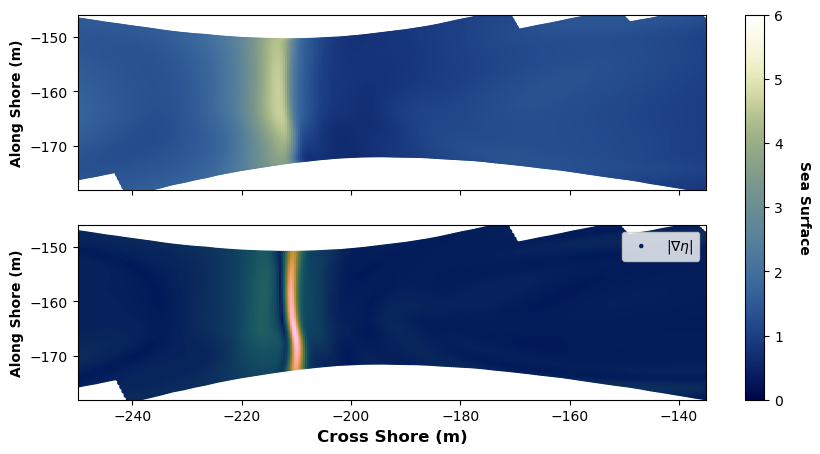

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri.cm as cmc

#Make the plot

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,5))
im1 = ax1.scatter(x, y, c=z, vmin=0, vmax=6, cmap=cmc.davos)
scat = ax2.scatter(x, y, c = dz, cmap=cmc.batlow, s =5, label =r'$|\nabla \eta|$')
ax2.legend(loc = 'upper right')
ax1.set_aspect('equal')
ax2.set_aspect('equal')

ax1.set_xlim(-250, -135)
ax1.set_ylim(-178, -146)
ax2.set_xlim(-250, -135)
ax2.set_ylim(-178, -146)

ax1.set_xticklabels([])


ax2.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
ax1.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)    
ax2.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)

cbar = fig.colorbar(im1, ax=[ax1, ax2], location='right', shrink=1.0, aspect=20, fraction = .05)
cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)

save = f"../latex/overleaf/figures/derivative.pdf"
plt.savefig(save, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Second derivative

In [8]:
laplacian = operator.second_grad()

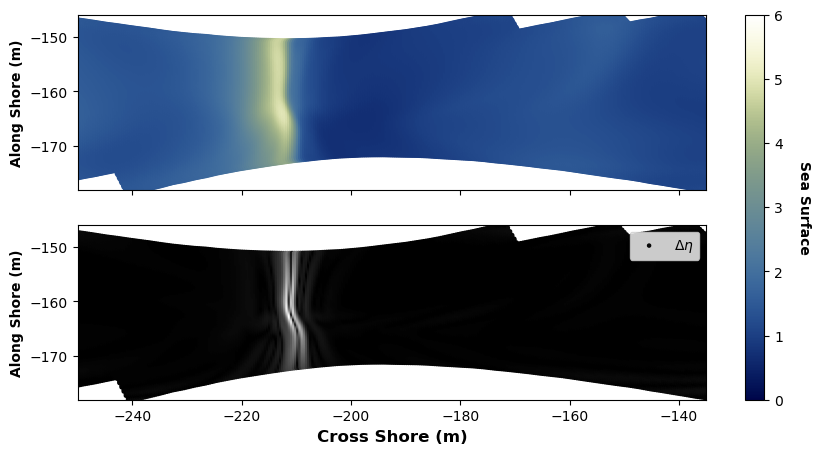

In [9]:
ddz = laplacian.detach().numpy()
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,5))
im1 = ax1.scatter(x, y, c=z, vmin=0, vmax=6, cmap=cmc.davos)
scat = ax2.scatter(x, y, c = ddz, cmap=cmc.grayC, s =5, label = r'$\Delta \eta$')
ax2.legend(loc = 'upper right')
ax1.set_aspect('equal')
ax2.set_aspect('equal')

ax1.set_xlim(-250, -135)
ax1.set_ylim(-178, -146)
ax2.set_xlim(-250, -135)
ax2.set_ylim(-178, -146)

ax1.set_xticklabels([])


ax2.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
ax1.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)    
ax2.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)

cbar = fig.colorbar(im1, ax=[ax1, ax2], location='right', shrink=1.0, aspect=20, fraction = .05)
cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)

# save = f"figures/frame_{frame:03d}.png"
# plt.savefig(save, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

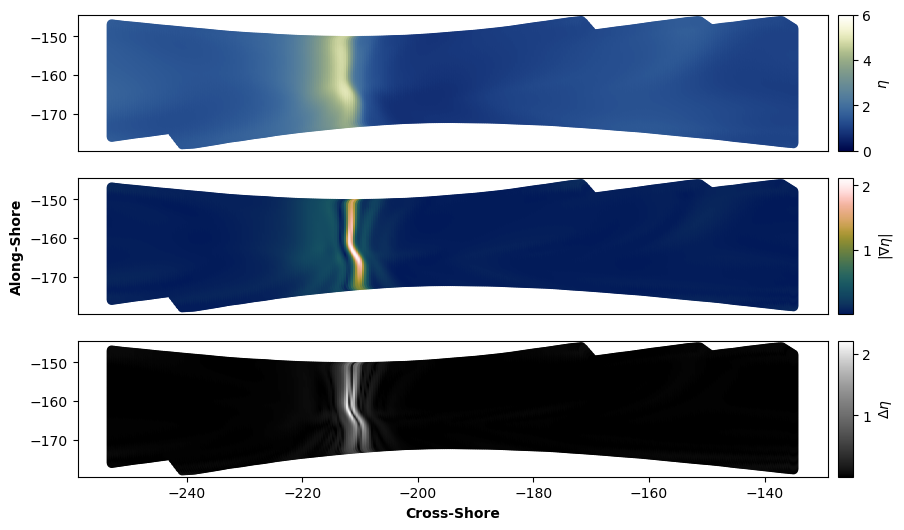

In [10]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
frac = .02
pd = .04
asc = 5
sh = 10

fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (10,6))

sc1 = ax1.scatter(x,y,c = z, cmap = cmc.davos, vmin = 0, vmax = 6)
sc2 = ax2.scatter(x,y,c = dz, cmap = cmc.batlowW)
sc3 = ax3.scatter(x,y,c = ddz, cmap = cmc.grayC)

divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="2%", pad=0.1)
fig.colorbar(sc1, cax=cax1, label =  r'$\eta$')

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
fig.colorbar(sc2, cax=cax2, label = r'$|\nabla \eta| $')

divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes("right", size="2%", pad=0.1)
fig.colorbar(sc3, cax=cax3, label = r'$\Delta \eta $')


ax1.set_xticks([])
ax2.set_xticks([])
ax3.set_xlabel('Cross-Shore', fontweight = 'bold')
ax2.set_ylabel('Along-Shore', fontweight = 'bold')

plt.show()

## Error Heat Map

### Plotting made easy

In [5]:
network_data = 'nets/siren/more_data_300_320.pt'
time = 30.2

In [ ]:
import torch
import numpy as np
from Modules.Neural_Net import Net
import Modules.preprocess as pp


#This defines where the data is
data  = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(300, 303, 1)
train_beams = list(range(0, 32))
model = torch.load(network_data, weights_only = False)

#This generates the data
train_data = pp.data_gen(data, beams = train_beams, frames=frames, normalize=model['scalers'], splits =.99)
train_dataloader, q  = train_data.get_dataloaders(train_data, batch_size=1, num_workers=4)

#This makes the model
net = Net(torch.sin, *model['model config']).to('cpu')
net.load_state_dict(model['model_state_dict'])
net.eval()



In [ ]:
from Modules.evaluate import Evaluator
from Modules.evaluate import pick_data

def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)

inputs = torch.load('Modules/plotting_region.pt', weights_only = True)
inputs = add_t(inputs, 30)


evalulator = Evaluator(net, scalers = model['scalers'], inputs=inputs)
pred_z = evalulator.net_eval()

raw = pick_data(data=data, beams= train_beams, frames =frames)
raw_in, raw_out = raw.data_out_numpy(30)
print(raw_in.shape)
raw_x = raw_in[:,0]
raw_y = raw_in[:,1]
raw_z = raw_out

x = inputs[:, 0].reshape(-1, 1)
y = inputs[:, 1].reshape(-1, 1)



(17635, 3)


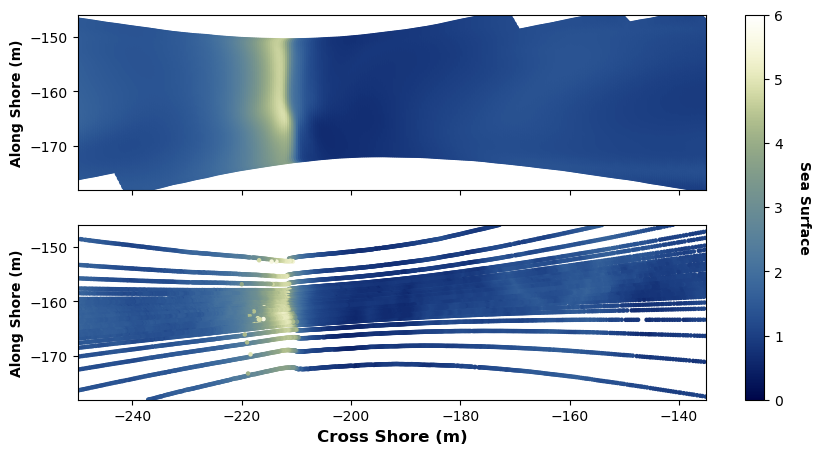

In [ ]:
' Make an error map, showing the regions of large discrepency.'

## Video Creation

- load net
- set time bounds on video
- plot NN on fixed plotting location
- run through and save all frames as pngs
- compile all into a movie


In [13]:
import numpy as np
network_data = 'nets/MSE/siren_200_400.pt'
time = np.linspace(20, 40, 250)

In [11]:
'helper functions'
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import os
import torch
from Modules.Neural_Net import Net



pltr = torch.load('Modules/plotting_region.pt', weights_only = True)
pltr_shape  = pltr[:,0:1].shape
model = torch.load(network_data, weights_only=False)
sc_in = torch.tensor(model['scalers'][0].scale_, dtype=torch.float32)
sc_out = torch.tensor(
            model['scalers'][1].scale_,
            dtype=torch.float32
        )

net = Net(torch.sin, *model['model config']).to('cpu')
net.load_state_dict(model['model_state_dict'])
net.eval()


def add_t(time):
    return torch.cat(
        [pltr, torch.ones_like(pltr[:, 0:1]) * time],
        dim=1
    ).to(dtype=torch.float32)


def net_eval(time):
    with torch.no_grad():
        # raw input
        x_raw = add_t(time).numpy()

        # input scaling (training-faithful)
        if model['scalers'] is not None:
            x_scaled = in_scaler.transform(x_raw)
            x_scaled = torch.tensor(x_scaled, dtype=torch.float32) * (torch.pi / 2)
        else:
            x_scaled = torch.tensor(x_raw, dtype=torch.float32)

        # forward pass
        y_net = net(x_scaled)

        # output unscale
        y_net = y_net.numpy()
        if model['scalers'] is not None:
            y = out_scaler.inverse_transform(y_net / (np.pi / 2))
        else:
            y = y_net

    return y.squeeze()


def plotting_coord(time):
    z = net_eval(time)
    x = pltr[:, 0].numpy()
    y = pltr[:, 1].numpy()
    return x, y, z



# function to make plot: UNFINISHED
def plot(x,y,z, prints=False):
    fig, ax = plt.subplots(figsize=(12,6))
    fig.patch.set_facecolor('lightgray')  # Figure background
    ax.set_facecolor('lightgray')
    sc = ax.scatter(x, y, c=z, cmap=cmc.davos, s=6, vmin = 0, vmax = 6)
    ax.set_xticks([])
    ax.set_yticks([])
    if prints:
        plt.show()

def plot_hexbin(x,y,z):
    fig, ax = plt.subplots(figsize=(12,6))

    hexbin = ax.hexbin(x, y, C=z, cmap=cmc.davos, gridsize=100, reduce_C_function=np.mean, vmin = 0, vmax = 6)
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title('Wave Height Prediction')
    plt.show()


In [14]:
import os

save_path = "figures/sin_200_400"
os.makedirs(save_path, exist_ok=True)  # makedirs, not mkdir; exist_ok, not check
for i, t in enumerate(time):  # enumerate to get index
    x, y, z = plotting_coord(t)
    plot(x, y, z)
    plt.savefig(f"{save_path}/{i:04d}.png")  # include filename with index
    plt.close()


In [ ]:
import torch
import matplotlib.pyplot as plt
from Modules.Neural_Net import Net
import cmcrameri.cm as cmc

plotting_region = torch.load('Modules/plotting_region.pt', weights_only = True)

model = torch.load(network_data, weights_only = False)
if model['scalers'] is not None:
    in_scaler, out_scaler = model['scalers']

time_scaler =  in_scaler.scale_[2]
t = time/time_scaler

# plotting loop for video gen
for ti in t:
    pass


8.660098921356772


In [37]:
'plotting data'
import matplotlib.pyplot as plt
import torch
import Modules.preprocess as pp
import numpy as np 
import cmcrameri.cm as cmc
import time

# n = 10000000
# probability = 0.8
# tbut = time.time()
# mask = torch.rand(n) < .9
# ver_mask  = ~(mask)
# input = torch.ones([n, 3])
# output = torch.ones([n, 1])
# train_input, train_output = [input[mask], output[mask]]
# ver_input, ver_output = [input[ver_mask], output[ver_mask]]
# tnow = time.time()

# print(f"Time to change data: {tnow - tbut}")
# print(train_input.shape, train_output.shape)
# print(train_input)
# print(ver_input.shape, ver_output.shape)


if __name__ == '__main__':
    data = torch.load('../../data/data.pt', weights_only=True)
    frames = np.arange(301, 302, 1)
    train_beams = list(range(0, 32))
    train_beams.remove(1)
    train_beams.remove(3)
    train_beams.remove(30)
    train_beams.remove(29)


    datasets = pp.data_gen(data, beams=train_beams, frames=frames,
                              normalize=None)
    
    train_dataloader, ver_dataloader = datasets.get_dataloaders(batch_size=1,
                                                   num_workers=4)

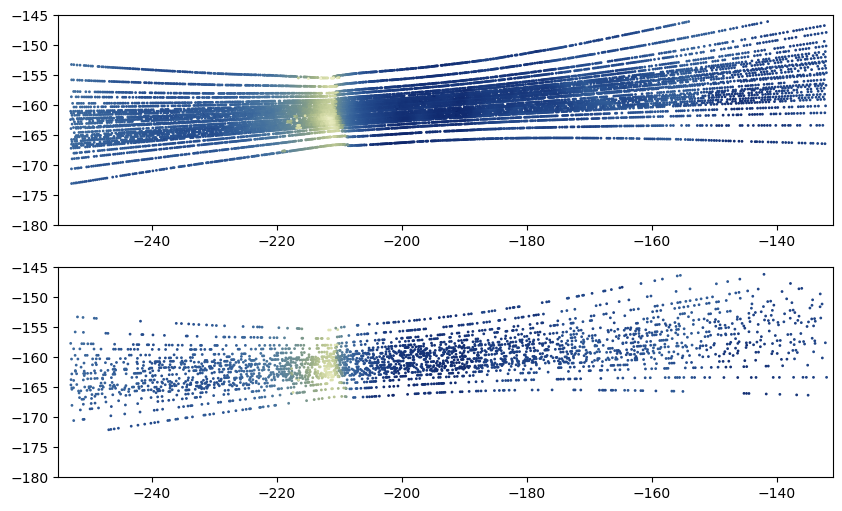

In [38]:
input_batch, output_batch = next(iter(train_dataloader))
ver_in, ver_out = next(iter(ver_dataloader))

x = input_batch.cpu().numpy().reshape(-1, 3)[:, 0]
y = input_batch.cpu().numpy().reshape(-1, 3)[:, 1]
z = output_batch.cpu().numpy().flatten()

xv = ver_in.cpu().numpy().reshape(-1, 3)[:, 0]
yv = ver_in.cpu().numpy().reshape(-1, 3)[:, 1]
zv = ver_out.cpu().numpy().flatten()


fig, (ax1, ax2) = plt.subplots(2, figsize =(10, 6))
ax1.scatter(x, y, c=z, 
            cmap=cmc.davos, label='True', s=1, vmin=0, vmax=6)

ax2.scatter(xv, yv, c=zv, 
            cmap=cmc.davos, label='True', s=1, vmin=0, vmax=6)
ax1.set_xlim(-255, -131)
ax1.set_ylim(-180, -145)

ax2.set_xlim(-255, -131)
ax2.set_ylim(-180, -145)
plt.show()

# Below here is old plotting attemps.

In [13]:

import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc



In [4]:
'net work'

# network_info = torch.load('nets/MSE/mse_0_2000.pt', weights_only=True)
choice = input('MSE or SPT? ')
if choice.lower() == 'mse':
    network_info = torch.load('nets/MSE/siren_290_310.pt', weights_only=False)
elif choice.lower() == 'spt':
    network_info = torch.load('nets/SPT/spt_e_100_a_5_f1.pt', weights_only=True)

model_config = network_info['model config']
net = Net(torch.cos, *model_config)
net.load_state_dict(network_info['model_state_dict'])

device = 'cpu'
net = net.to(device)
net.eval()

print('done')

KeyboardInterrupt: Interrupted by user

In [15]:
'data prep'

all_data = torch.load('../../data/data.pt', weights_only= True)
frame = 305
ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
grid_xy, X, Y = pre_pro.create_grid(device)
pd = torch.load('Modules/plotting_region.pt', weights_only=True).to(torch.float32)


ver_xy, ver_z = pre_pro.prepare_tensors(ver_data, device)
train_xy, train_z = pre_pro.prepare_tensors(train_data, device)
test_xy, test_z = pre_pro.prepare_tensors(test_data, device)
all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)
cen_xy, cen_z = pre_pro.prepare_tensors(cen_beam[0], device)

save_path = 'plots/'

new_net = NetWrapper(net, frame = frame)



In [16]:
'Using the plotting region to make plots'

# network = NetWrapper(net, frame = 302)
def plot(newtork):
    try:
        with torch.no_grad():
            pred = network(pd).cpu()
            # print(f"Success! pred shape: {pred.shape}")
    except Exception as e:
        print(f"Error in network call: {e}")

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,5))
    im1 = ax1.scatter(pd[:,0].cpu(), pd[:,1].cpu(), c=pred[:,0], vmin=0, vmax=6, cmap=cmc.davos)
    scat = ax2.scatter(all_data_xy[:,0].detach().cpu(), all_data_xy[:,1].detach().cpu(), c=all_data_z[:,0].detach().cpu(), vmin=0, vmax=6, cmap=cmc.davos, s =5)

    ax1.set_aspect('equal')
    ax2.set_aspect('equal')

    ax1.set_xlim(-250, -135)
    ax1.set_ylim(-178, -146)
    ax2.set_xlim(-250, -135)
    ax2.set_ylim(-178, -146)

    ax1.set_xticklabels([])


    ax2.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
    ax1.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)    
    ax2.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)

    cbar = fig.colorbar(im1, ax=[ax1, ax2], location='right', shrink=1.0, aspect=20, fraction = .05)
    cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)

    # save = f"figures/frame_{frame:03d}.png"
    # plt.savefig(save, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

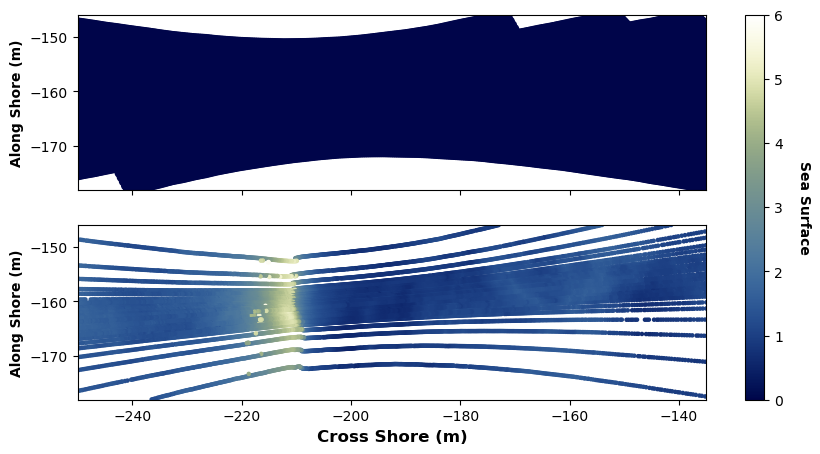

In [17]:
frame = 301

ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)

network = NetWrapper(net, frame = frame)
plot(network)

Processing frames:   0%|          | 0/100 [00:00<?, ?it/s]

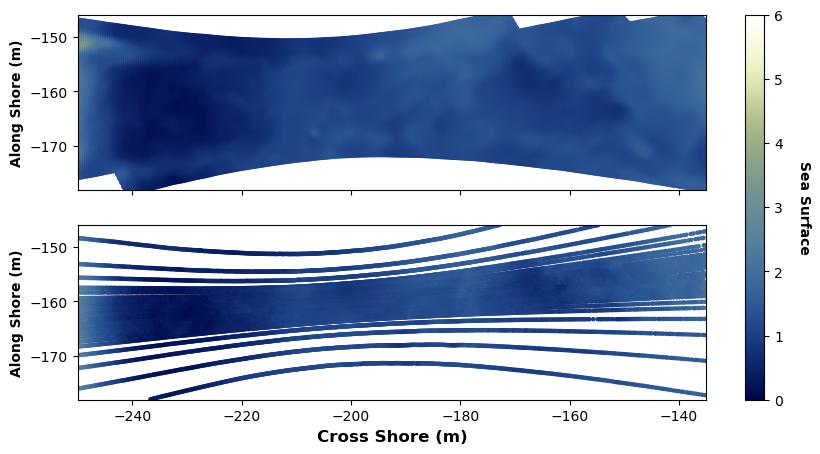

Processing frames:   1%|          | 1/100 [00:03<06:35,  3.99s/it]


KeyboardInterrupt: 

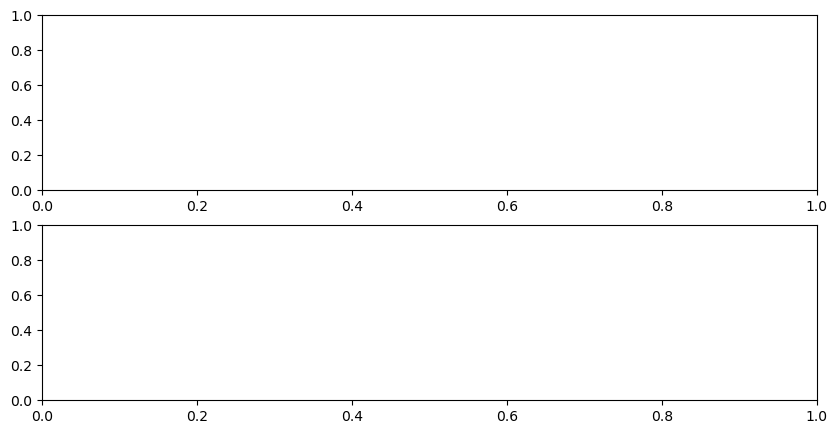

In [7]:

all_data = torch.load('../../data/data.pt', weights_only= True)
for frame in tqdm(range(250,350), desc="Processing frames"):
    
    ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
    all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)

    network = NetWrapper(net, frame = frame)
    plot(network)

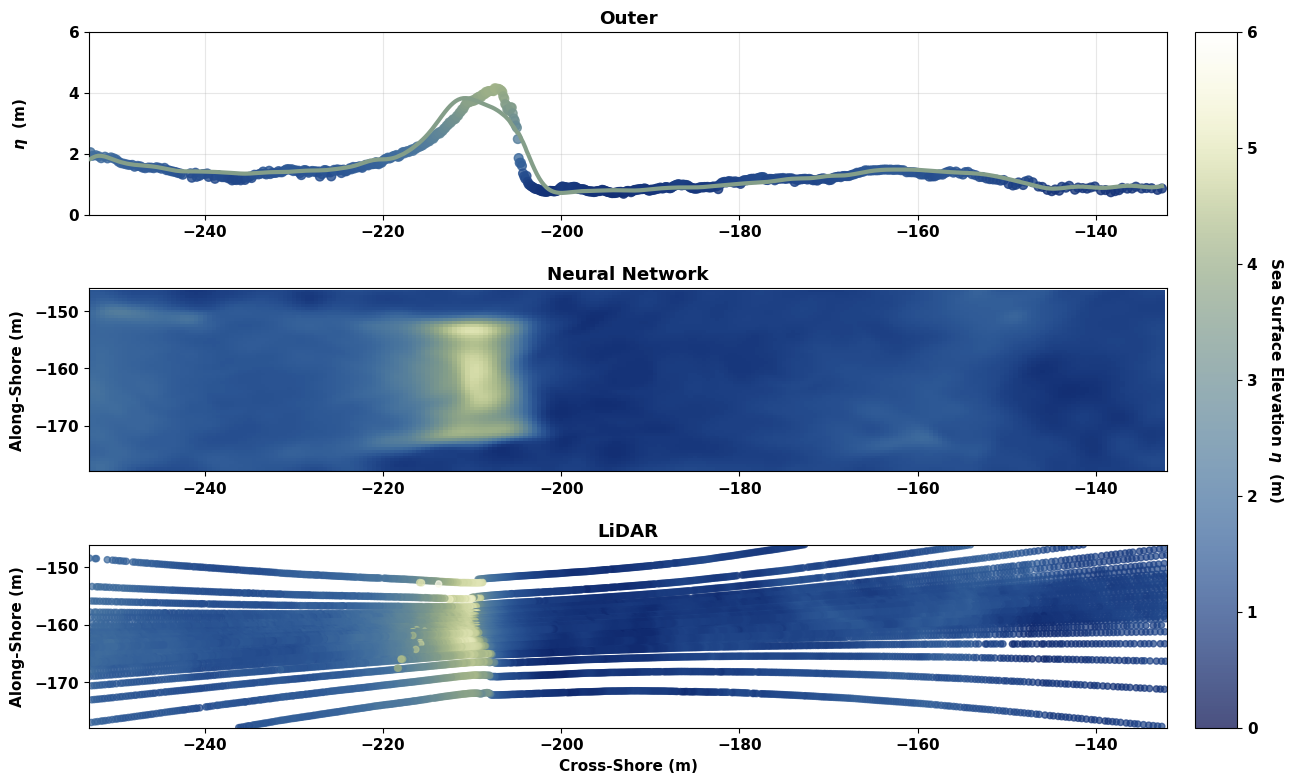

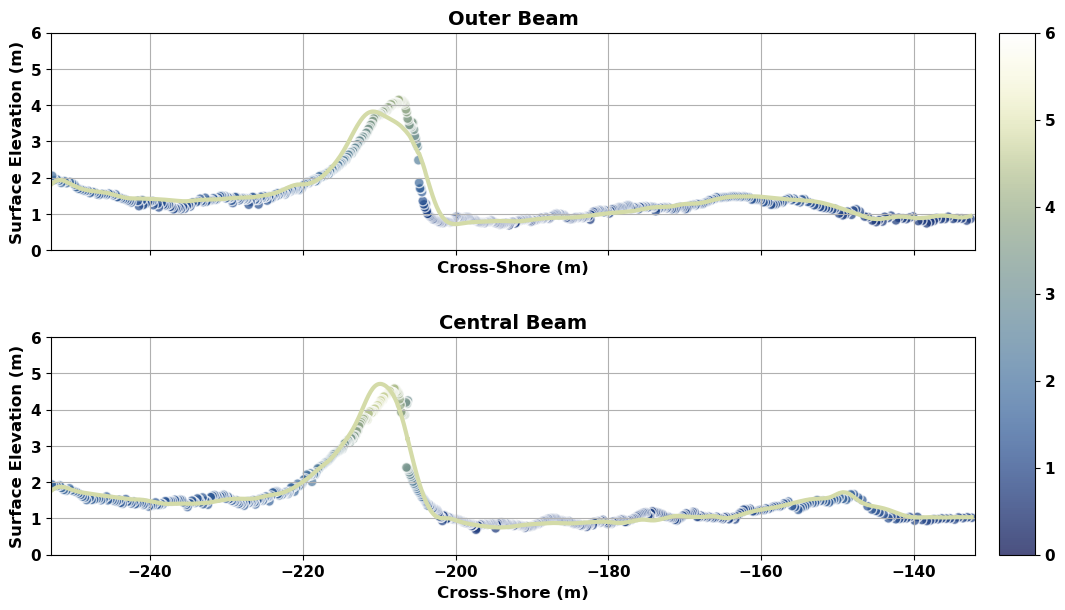

(2.836862564086914, 3.587099552154541, np.float32(1.4013699))

In [7]:
pre_pro.plots(ver_xy, ver_z, grid_xy, X, Y, all_beam_data, new_net, 
                                train_xy, train_z, test_xy, test_z, save_path, cen_xy, cen_z,
                                frame = frame, show = True)

In [ ]:
'Now we just want to plot on frames 0 to 500 and make a hist to see ow good it does'

frame = list(range(500))

trains =[]
tests = []
results = []
save_path = 'plots_new/'

for i in tqdm(frame, desc = 'Frames'):
    ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=i)
    ver_xy, ver_z = pre_pro.prepare_tensors(ver_data, device)
    train_xy, train_z = pre_pro.prepare_tensors(train_data, device)
    test_xy, test_z = pre_pro.prepare_tensors(test_data, device)
    all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)
    cen_xy, cen_z = pre_pro.prepare_tensors(cen_beam[0], device)

    new_net = NetWrapper(net, frame = i)

    train, test, mean = pre_pro.plots(ver_xy, ver_z, grid_xy, X, Y, all_beam_data, new_net, 
                                    train_xy, train_z, test_xy, test_z, save_path, cen_xy,
                                    cen_z, frame = i, show = True)
    
    rms = (test + train)/2
    if i % 2 ==0 :
        trains.append(rms)

    if i % 2 == 1:
        tests.append(rms)

    results.append(pre_pro.preformance(grid_xy,all_data_xy, all_data_z, new_net, 
                                train_xy, train_z, test_xy, test_z,bins= 240, save_path=None))
        

torch.save({'train': trains,
            'test': tests}, save_path + 'train_test.pt')

torch.save({'results': results}, save_path + 'results.pt')




In [ ]:
'Avergae gradient in x = [-220, -180] y = [-170, -155] as a function of time'

x = torch.linspace(-220, -180, 40)
y = torch.linspace(-170, -155, 30)
X, Y = torch.meshgrid(x, y, indexing='ij')
grid_xy = torch.stack((X.flatten(), Y.flatten()), dim=-1).to(device)
def add_t(grid_xy, t):
    t = torch.ones(grid_xy.shape[0], 1).to(device) * t
    grid_xyt = torch.cat((grid_xy, t), dim=-1)
    return grid_xyt    

def net_diff(net, grid_xyt):
    pred = net(grid_xyt).sum()
    torch.autograd.backward(pred)
    
    return pred


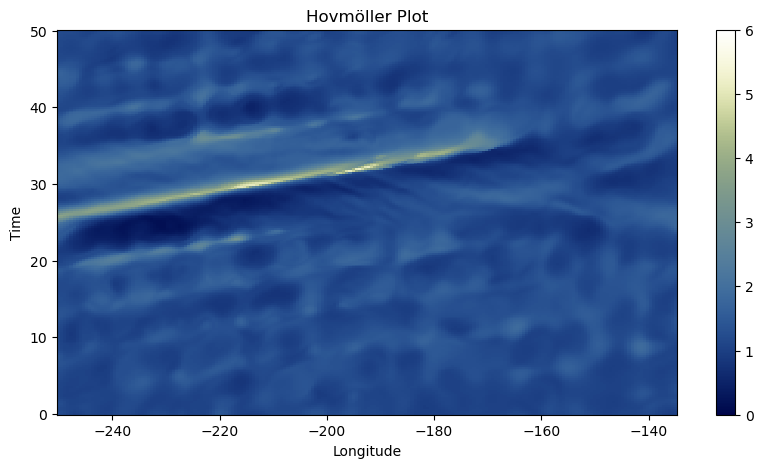

In [8]:
'Hovomollar plot'

x = torch.linspace(-250, -135, 200)
y = -162.5
t = torch.linspace(0, 50, 200)
X, T = torch.meshgrid(x, t, indexing='ij')
grid_xyt = torch.stack((X.flatten(), torch.ones(X.numel()).to(device)*y, T.flatten()), dim=-1).to(device)


with torch.no_grad():
    pred = net(grid_xyt).cpu().numpy()

    Z = pred[:,0].reshape(X.shape)

fig, ax = plt.subplots(figsize=(10,5))
im = ax.pcolormesh(X, T, Z, vmin=0, vmax=6, cmap=cmc.davos, shading='auto')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Longitude')
ax.set_ylabel('Time')
ax.set_title('Hovmöller Plot')
plt.savefig('../latex/overleaf/figures/hovmoller_plot.pdf', dpi=300, bbox_inches='tight')



In [ ]:
import numpy as np
from scipy.interpolate import griddata

delta = .05
resulution = 130
f = 0

pbar = tqdm(total = 500, desc="Creating Hovmoller frames")
while delta < 100:
    pbar.update(1)
    delta += .2
    f+=1
    x = torch.linspace(-250, -135, resulution)
    y = -162.5
    t = torch.linspace(0+delta, 50+delta, resulution)
    X, T = torch.meshgrid(x, t, indexing='ij')
    grid_xyt = torch.stack((X.flatten(), torch.ones(X.numel()).to(device)*y, T.flatten()), dim=-1).to(device)


    with torch.no_grad():
        pred = net(grid_xyt).cpu().numpy()

        Z = pred[:,0].reshape(X.shape)


    x_orig = torch.linspace(-250, -135, resulution)
    t_orig = torch.linspace(0+delta, 50+delta, resulution)
    X_orig, T_orig = torch.meshgrid(x_orig, t_orig, indexing='ij')

    # Higher resolution grid for plotting
    x_smooth = np.linspace(-250, -135, 300)
    t_smooth = np.linspace(0 + delta, 50 + delta, 300)
    X_smooth, T_smooth = np.meshgrid(x_smooth, t_smooth, indexing='ij')

    # Convert PyTorch tensors to NumPy arrays before interpolation
    points = np.column_stack((X_orig.numpy().flatten(), T_orig.numpy().flatten()))
    values = Z.flatten()  # Z should already be numpy from .cpu().numpy()
    Z_smooth = griddata(points, values, (X_smooth, T_smooth), method='cubic')

    fig, ax = plt.subplots(figsize=(10,5))
    im = ax.pcolormesh(X_smooth, T_smooth, Z_smooth, vmin=0, vmax=6, cmap=cmc.davos, shading='gouraud')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)
    ax.set_xlim( -250, -135)
    ax.set_ylim( 0+delta, 50+delta)    
    ax.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
    ax.set_ylabel('Time (seconds)', fontweight = 'bold', fontsize = 12)

    plt.savefig(f'../../S3_talk/hovmoller/hovmoller_{f}.png', dpi=300, bbox_inches='tight')
    plt.close()

Creating Hovmoller frames: 100%|██████████| 500/500 [20:56<00:00,  2.48s/it]

### Training Curves

- Training Loss
- Trainng MSE Loss
- Training Regularized Loss

- Verification Loss